In [1]:
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
from scipy.interpolate import PchipInterpolator

In [2]:
df_shallow = pd.read_csv("./shallow.csv")
R_shallow = df_shallow["R"].values
m_shallow = df_shallow["m"].values
df_deep = pd.read_csv("./deep.csv")
R_deep = df_deep["R"].values
m_deep = df_deep["m"].values

Text(0.5, 1.0, 'Kuang and Bretherton (2006)')

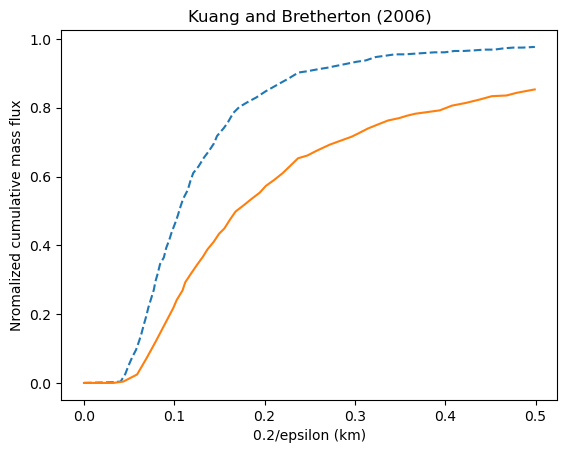

In [122]:
plt.plot(R_shallow,m_shallow,"--",label="shallow")
plt.plot(R_deep,m_deep,label="deep")
plt.xlabel("0.2/epsilon (km)")
plt.ylabel("Normalized cumulative mass flux")
plt.title("Kuang and Bretherton (2006)")

In [105]:
from scipy.interpolate import UnivariateSpline
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter


def fit_cdf(R, m,window=100):
    x = R[R>0]
    cdf = m[R>0]
    # sort data
    idx = np.argsort(x)
    x_sort = np.asarray(x)[idx]
    cdf_sort = np.asarray(cdf)[idx]

    # smoothing spline
    spl = UnivariateSpline(
        x_sort,
        cdf_sort,
        k=1,       # cubic spline
        s=0.000001     # smoothing strength -- tune this
    )

    x_fit = np.linspace(0, 0.8, 1000)
    cdf_fit = spl(x_fit)
    cdf_fit[cdf_fit>1] = 1
    
    dF_dR = savgol_filter(
    cdf_fit,
    window_length=window,
    polyorder=2,
    deriv=1,
    delta=x_fit[1] - x_fit[0]
    )
    dF_dR[dF_dR<0] = 0
    
    return x_fit[x_fit<0.5], dF_dR[x_fit<0.5]

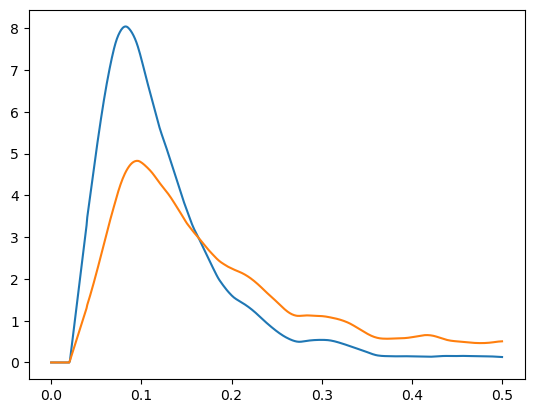

In [106]:
plt.plot(*fit_cdf(R_shallow, m_shallow))
plt.plot(*fit_cdf(R_deep, m_deep))
# plt.xlim(0,0.5)

In [107]:
def get_epsilon_pdf(R_fit, dF_dR):
    mask = R_fit > 0

    R_use = R_fit[mask]
    dF_dR_use = dF_dR[mask]

    epsilon = 0.2 / R_use

    dF_depsilon = -dF_dR_use * 0.2 / epsilon**2
    
    idx = np.argsort(epsilon)

    epsilon = epsilon[idx]
    dF_depsilon = dF_depsilon[idx]
    massflux_epsilon = -dF_depsilon
    return epsilon, massflux_epsilon

In [108]:
ep_shallow, m_ep_shallow = get_epsilon_pdf(*fit_cdf(R_shallow, m_shallow))
ep_deep, m_ep_deep = get_epsilon_pdf(*fit_cdf(R_deep, m_deep))

In [115]:
def R_cdf_to_epsilon_cdf(R, cdf_R):
    mask = R > 0

    R = np.asarray(R)[mask]
    cdf_R = np.asarray(cdf_R)[mask]

    epsilon = 0.2 / R

    # Because epsilon decreases as R increases
    cdf_epsilon = 1 - cdf_R

    # sort by increasing epsilon
    idx = np.argsort(epsilon)

    return epsilon[idx], cdf_epsilon[idx]

Text(0, 0.5, 'Normalized cumulative mass flux')

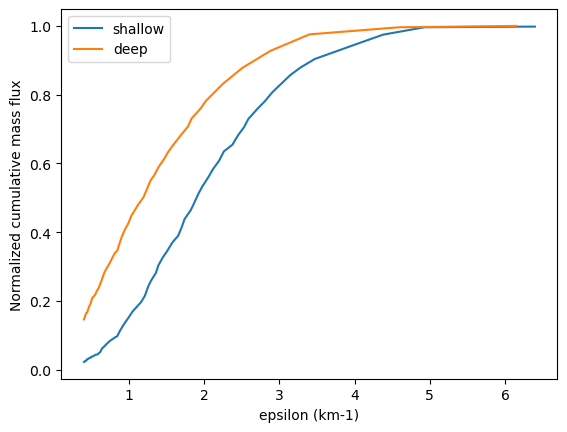

In [123]:

plt.plot(*R_cdf_to_epsilon_cdf(R_shallow,m_shallow),label="shallow")
plt.plot(*R_cdf_to_epsilon_cdf(R_deep,m_deep),label="deep")
plt.legend()
plt.xlabel("epsilon (km-1)")
plt.ylabel("Normalized cumulative mass flux")

In [185]:
def distribution_profile(nbins=50, skew="right"):
    '''
    Generate a distribution of plumes with different entrainment rates.
    
    '''
    x = np.linspace(0, 1, nbins)

    # Gamma parameters chosen to give a similar low-x peak
    shape = 4
    scale = 0.05

    # standard deviation for the central normal case
    sigma = np.sqrt(shape) * scale
    mean = np.sqrt(shape)*sigma
    
    if skew == "right":
        pdf = gamma.pdf(x, a=shape, scale=scale)
        Afac=0.05
    elif skew == "right_wide":
        pdf = gamma.pdf(x, a=2, scale=shape*scale/2)
        Afac=0.05
    elif skew =="right_narrow":

        pdf = gamma.pdf(x, a=16, scale=shape*scale/16)
        Afac=0.05
    elif skew == "normal":
        mu = 0.5
        pdf = norm.pdf(x, loc=mu, scale=sigma)
        Afac=0.05
    elif skew == "normal_wide":
        mu = 0.5
        pdf = norm.pdf(x, loc=mu, scale=sigma*1.3)
        Afac=0.05
    elif skew == "normal_narrow":
        mu = 0.5
        pdf = norm.pdf(x, loc=mu, scale=sigma/2)
        Afac=0.05
    elif skew == "left":
        # mirror the right-skewed gamma around x = 0.5
        pdf = gamma.pdf(1 - x, a=shape, scale=scale)
        Afac=0.05
    elif skew == "left_wide":
        pdf = gamma.pdf(1-x, a=2, scale=shape*scale/2)
        Afac=0.05
    elif skew == "left_narrow":
        pdf = gamma.pdf(1 - x, a=16, scale=shape*scale/16)
        Afac=0.05
    else:
        raise ValueError(
            f"Input: {skew} is not a valid option. "
            "Choose from 'right', 'normal', 'left', "
            "'strong-low-entrain', or 'strong-high-entrain'."
        )
    
    return x, pdf, Afac

In [181]:
from scipy.integrate import cumulative_trapezoid
from scipy.stats import gamma,norm 

Text(0.5, 1.0, 'Idealised gamma distribution')

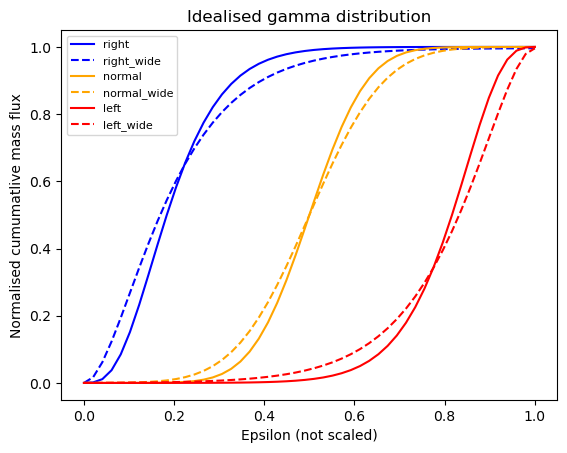

In [188]:
x, pdf, _ = distribution_profile(nbins=50, skew="right")
cdf = cumulative_trapezoid(pdf, x, initial=0)
plt.plot(x,cdf,color="b",label="right")

x, pdf, _ = distribution_profile(nbins=50, skew="right_wide")
cdf = cumulative_trapezoid(pdf, x, initial=0)
plt.plot(x,cdf,"b--",label="right_wide")
x, pdf, _ = distribution_profile(nbins=50, skew="normal")
cdf = cumulative_trapezoid(pdf, x, initial=0)
plt.plot(x,cdf,color="orange",label="normal")
x, pdf, _ = distribution_profile(nbins=50, skew="normal_wide")
cdf = cumulative_trapezoid(pdf, x, initial=0)
plt.plot(x,cdf,"--",color="orange",label="normal_wide")

x, pdf, _ = distribution_profile(nbins=50, skew="left")
cdf = cumulative_trapezoid(pdf, x, initial=0)
plt.plot(x,cdf,color="red", label="left")
x, pdf, _ = distribution_profile(nbins=50, skew="left_wide")
cdf = cumulative_trapezoid(pdf, x, initial=0)
plt.plot(x,cdf,"r--",label="left_wide")
plt.legend(loc="upper left", fontsize=8)
plt.xlabel("Epsilon (not scaled)")
plt.ylabel("Normalised cumumatlive mass flux")
plt.title("Idealised gamma distribution")

Text(0, 0.5, 'Mass flux')

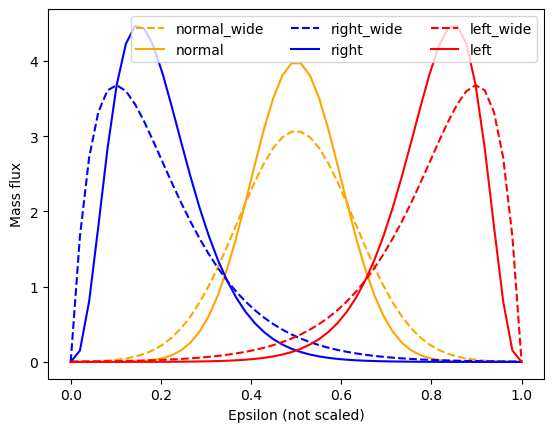

In [186]:
x, pdf, _ = distribution_profile(nbins=50, skew="normal_wide")
plt.plot(x,pdf,"--",color="orange",label="normal_wide")

x, pdf, _ = distribution_profile(nbins=50, skew="normal")
plt.plot(x,pdf,color="orange",label="normal")

x, pdf, _ = distribution_profile(nbins=50, skew="right_wide")
plt.plot(x,pdf,"--",color="blue",label="right_wide")
x, pdf, _ = distribution_profile(nbins=50, skew="right")
plt.plot(x,pdf,color="blue",label="right")

x, pdf, _ = distribution_profile(nbins=50, skew="left_wide")
plt.plot(x,pdf,"--",color="red",label="left_wide")
x, pdf, _ = distribution_profile(nbins=50, skew="left")
plt.plot(x,pdf,color="red",label="left")

plt.legend(ncol=3)
plt.xlabel("Epsilon (not scaled)")
plt.ylabel("Mass flux")